Advitiya Apurv 24EE10029, Afrin Munshi 24EE10030

In [44]:
from matplotlib import pyplot as plt
import numpy as np
import math
import pandas as pd
import cvxpy as cp

$$\phi(\mathbf{x}) = [1, x_1, x_2, x_3, x_4, x_1^2, x_2^2, x_3^2, x_4^2, x_1x_2, x_1x_3, x_1x_4, x_2x_3, x_2x_4, x_3x_4]$$
is our feature vector with dimension = 1x15

In [45]:
def err_cal(w,w_star):
    sol=w-w_star
    norm=math.sqrt(np.sum(sol**2))
    return norm

w has dimension 15x1

$$L = \|\phi(\mathbf{x})\mathbf{w} - y\|_2^2$$

In [46]:
def func(phix,w,y):
    sol=phix@w-y
    solution=np.linalg.norm(sol)**2
    #print(sol)

    return solution

$$\nabla_{\mathbf{w}} L = 2\phi(\mathbf{x})^T (\phi(\mathbf{x})\mathbf{w} - y)$$

In [47]:
def gradient(phix,w,y):
    sol=(phix@w-y)
    sol=2*np.transpose(phix)@sol
    return sol

In [48]:
def grad_desc(w,eta,phix,y):
    sol=w-eta*gradient(phix,w,y)
    return sol

In [49]:
def accel_descent(k,w,phix,y,eta):
    global prev
    temp=w-eta*gradient(phix,w,y)
    n=math.sqrt(k)
    sol=(1+(n-1)/(n+1))*temp-(n-1)/(n+1)*prev
    prev=np.copy(temp)
    return sol

In [50]:
def schos(eta,w,phix,y):
    sol=w-eta*gradient(phix,w,y)
    return sol

In [51]:



N = 100

X=pd.read_csv("X_Data.csv",header=None).to_numpy()
X=np.transpose(X)



In [52]:

y=pd.read_csv("Y_Data.csv",header=None).to_numpy()
y=np.transpose(y)




In [53]:
phix=np.array(np.ones(N))
for i in range(4):
    phix=np.column_stack((phix,X[:,i]))
for i in range(4):
    for j in range(i,4):
        phix=np.column_stack((phix,X[:,i]*X[:,j]))


Dimension of phix=(100,15)


In [54]:
w=np.random.uniform(0,0,size=(15,1))
wcopy=np.copy(w)

$$w^* = [\Phi(\hat{x})^T \Phi(\hat{x})]^{-1} \Phi(\hat{x})^T \hat{y}$$

In [55]:
#w_star = np.linalg.lstsq(phix, y, rcond=None)[0]
w_star = np.linalg.solve(phix.T @ phix, phix.T @ y)
print(w_star)

[[ 5.47014258e-13]
 [-3.34898256e-14]
 [ 5.00000000e+00]
 [-9.13460987e-14]
 [ 3.34771134e-14]
 [-2.00000000e+00]
 [ 2.14447051e-15]
 [ 7.00000000e+00]
 [-4.96845692e-15]
 [-6.43461237e-15]
 [-5.91479905e-15]
 [-5.62111897e-15]
 [-1.32494746e-14]
 [ 1.60000000e+01]
 [-1.14055740e-14]]


In [56]:
error=(y-phix@w_star).flatten()

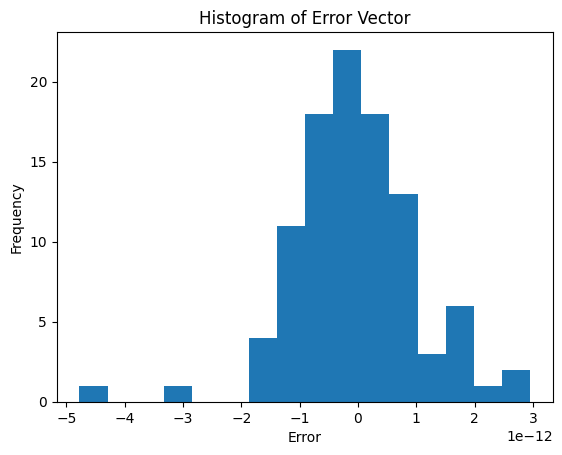

In [57]:
plt.hist(error, bins='auto')
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Histogram of Error Vector")
plt.show()

The histogram has a bell curve like appearance, with a peak at 0, signifying that the data is fit well by the model

In [58]:
hess=2*np.transpose(phix)@phix

In [59]:
eigvals = np.linalg.eigvals(hess)
beta=max(eigvals)
alpha=min(eigvals)
eta=1/beta
kappa=beta/alpha

In [60]:
lygrad=[]
lygerr=[]
lx=[]

In [61]:
for i in range(0,1000,1):
    lygrad.append(math.log(func(phix,w,y)))
    lygerr.append(math.log(err_cal(w,w_star)))
    lx.append(i)
    w=grad_desc(w,eta,phix,y)


In [62]:
w=np.copy(wcopy)
prev=np.copy(wcopy)

In [63]:
lyascg=[]
lyascerr=[]

In [64]:
for i in range(0,1000,1):
    lyascg.append(math.log(func(phix,w,y)))
    lyascerr.append(math.log(err_cal(w,w_star)))
    w=accel_descent(kappa,w,phix,y,eta)

In [65]:
w=np.copy(wcopy)
lysch=[]
lyscerr=[]

In [66]:
for i in range(0,1000,1):
    lysch.append(math.log(func(phix,w,y)))
    lyscerr.append(math.log(err_cal(w,w_star)))
    n=np.random.randint(low=0,high=100)
    w=schos(eta/math.sqrt(1+i),w,(phix[n]).reshape(1,-1),y[n].reshape(-1,1))


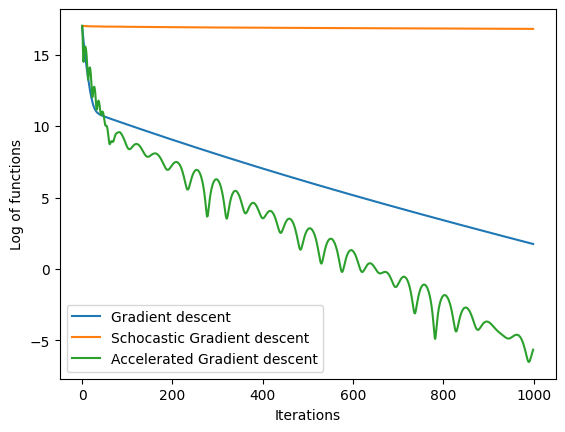

In [67]:
plt.plot(lx,lygrad,label="Gradient descent")
plt.plot(lx,lysch,label="Schocastic Gradient descent")
plt.plot(lx,lyascg,label="Accelerated Gradient descent")
plt.xlabel("Iterations")
plt.ylabel("Log of functions")
plt.legend()
plt.show()

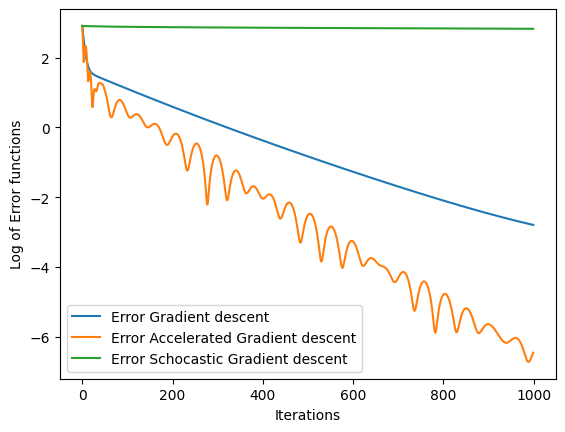

In [68]:
plt.plot(lx,lygerr,label="Error Gradient descent")
plt.plot(lx,lyascerr,label="Error Accelerated Gradient descent")
plt.plot(lx,lyscerr,label="Error Schocastic Gradient descent")
plt.xlabel("Iterations")
plt.ylabel("Log of Error functions")
plt.legend()
plt.show()

Gradient Descent is linear-ish. Accelerated gradient descent has a lot of fluctuations. Stochastic Gradient Descent has a very low convergence rate


In [69]:
x=X[0:10]

In [70]:
phixn=phix[0:10]
y10=y[0:10]
#w_star10 = np.linalg.lstsq(phixn, y10, rcond=None)[0]
w_star10= np.linalg.solve(phixn.T @ phixn, phixn.T @ y10)
error10=(y10-phixn@w_star10).flatten()

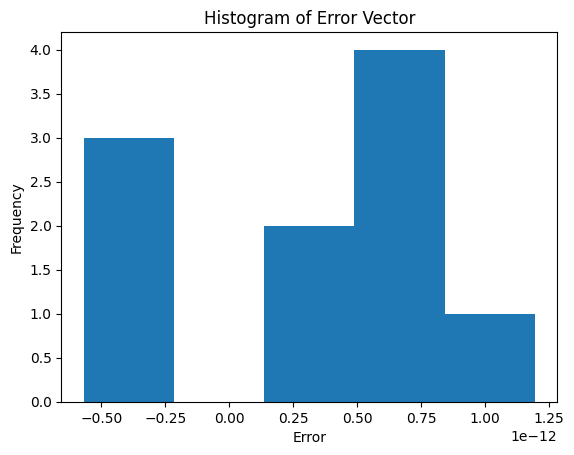

In [71]:
plt.hist(error10, bins='auto')
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Histogram of Error Vector")
plt.show()

This shows that there are more than 1 optimal solutions and the bell curve is skewed. Since there are only 10 values and 15 parameters we will generate infinite solutions to this set of linear equations

In [75]:
d=15
lambda_vals = [0.01, 0.1, 1.0]

w_reg_solutions = {}

for lam in lambda_vals:
    w = cp.Variable(d)

    objective = cp.Minimize(
        cp.sum_squares(phix @ w - y) + lam * cp.norm1(w)
    )

    prob = cp.Problem(objective)
    prob.solve()

    w_reg_solutions[lam] = w.value


In [78]:
w_reg_solutions

{0.01: array([-2.84016018e+01,  2.00188209e-12,  5.11321638e-12,  4.40926951e-12,
        -3.58604515e-11, -1.38006447e-11, -8.84137262e-12,  6.84107039e-12,
        -9.32610773e-12, -1.90233526e-11, -1.95777963e-12,  4.96373837e-13,
        -3.47439658e-11,  8.77709756e-12, -2.37230101e-11]),
 0.1: array([-2.84015546e+01, -1.57909378e-07, -2.99359584e-08, -7.02437495e-07,
        -2.89801987e-07, -2.71864106e-07, -5.47891396e-08,  1.09842565e-07,
        -1.20195908e-07, -3.29327357e-07,  2.53325421e-08,  6.17209058e-08,
        -4.38211323e-07,  1.64783395e-08, -3.55020929e-07]),
 1.0: array([-2.84012774e+01, -9.42693643e-07,  9.97885032e-07, -4.35893897e-06,
        -1.66663820e-06, -1.76508094e-06, -4.34600397e-07,  4.91573162e-07,
        -8.60350603e-07, -1.99015738e-06,  2.36923140e-07,  2.53271990e-07,
        -2.81003392e-06, -8.61469822e-08, -2.41169173e-06])}

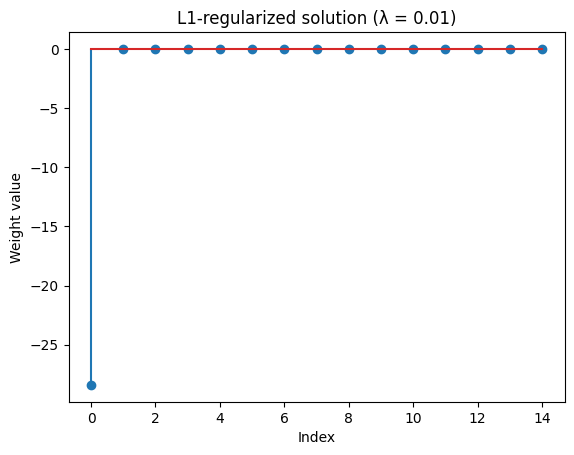

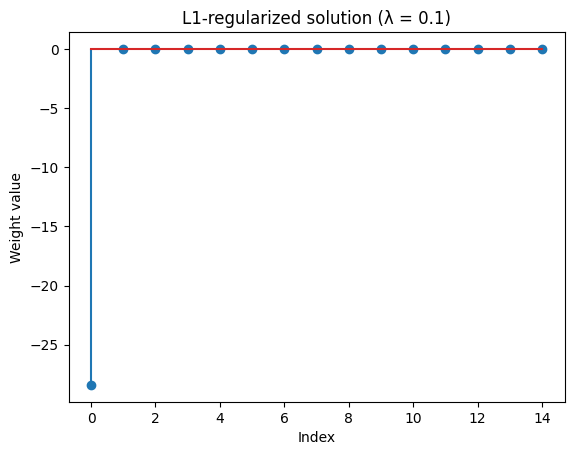

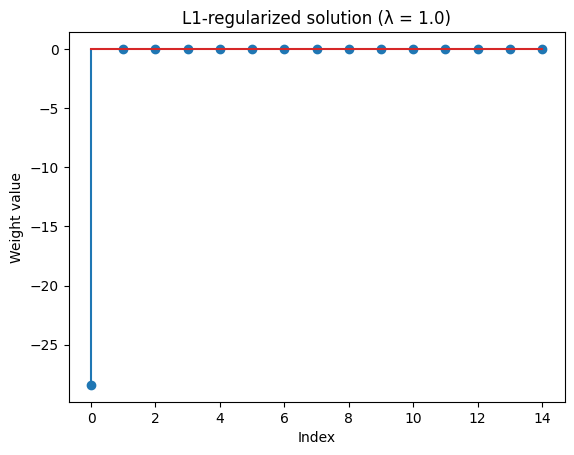

In [81]:
for lam, w_reg in w_reg_solutions.items():
    plt.stem(w_reg, label=f"λ = {lam}")
    plt.title(f"L1-regularized solution (λ = {lam})")
    plt.xlabel("Index")
    plt.ylabel("Weight value")
    plt.show()


In [83]:
w_star = np.linalg.lstsq(phix, y, rcond=None)[0]

print("Nonzero entries (unregularized):",
      np.sum(np.abs(w_star) > 1e-6))

for lam, w_reg in w_reg_solutions.items():
    print(f"Nonzero entries (λ={lam}):",
          np.sum(np.abs(w_reg) > 1e-6))


Nonzero entries (unregularized): 4
Nonzero entries (λ=0.01): 1
Nonzero entries (λ=0.1): 1
Nonzero entries (λ=1.0): 7


We are getting w's which are close but different